In [ ]:
import pandas as pd


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving features_30_sec.csv to features_30_sec (1).csv


In [ ]:
df = pd.read_csv('features_30_sec.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 60)
['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [ ]:
df.tempo

,tempo
0,123.046875
1,67.999589
2,161.499023
3,63.024009
4,135.999178
...,...
995,103.359375
996,117.453835
997,129.199219
998,73.828125


In [ ]:
df.spectral_centroid_mean

,spectral_centroid_mean
0,1784.165850
1,1530.176679
2,1552.811865
3,1070.106615
4,1835.004266
...,...
995,2008.149458
996,2006.843354
997,2077.526598
998,1398.699344


In [ ]:
df.zero_crossing_rate_mean

,zero_crossing_rate_mean
0,0.083045
1,0.056040
2,0.076291
3,0.033309
4,0.101461
...,...
995,0.089227
996,0.097664
997,0.121823
998,0.048724


In [ ]:
df['label'].value_counts()

,count
label,
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100


In [ ]:
df['label'].value_counts()

,count
label,
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,100
metal,100
pop,100
reggae,100


In [ ]:
X = df.drop(columns=['filename', 'length', 'label'])
y = df['label']

print(X.shape, y.shape)

(1000, 57) (1000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform only, not fit

In [ ]:
print(X_train_scaled.shape, X_test_scaled.shape)

(750, 57) (250, 57)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.684


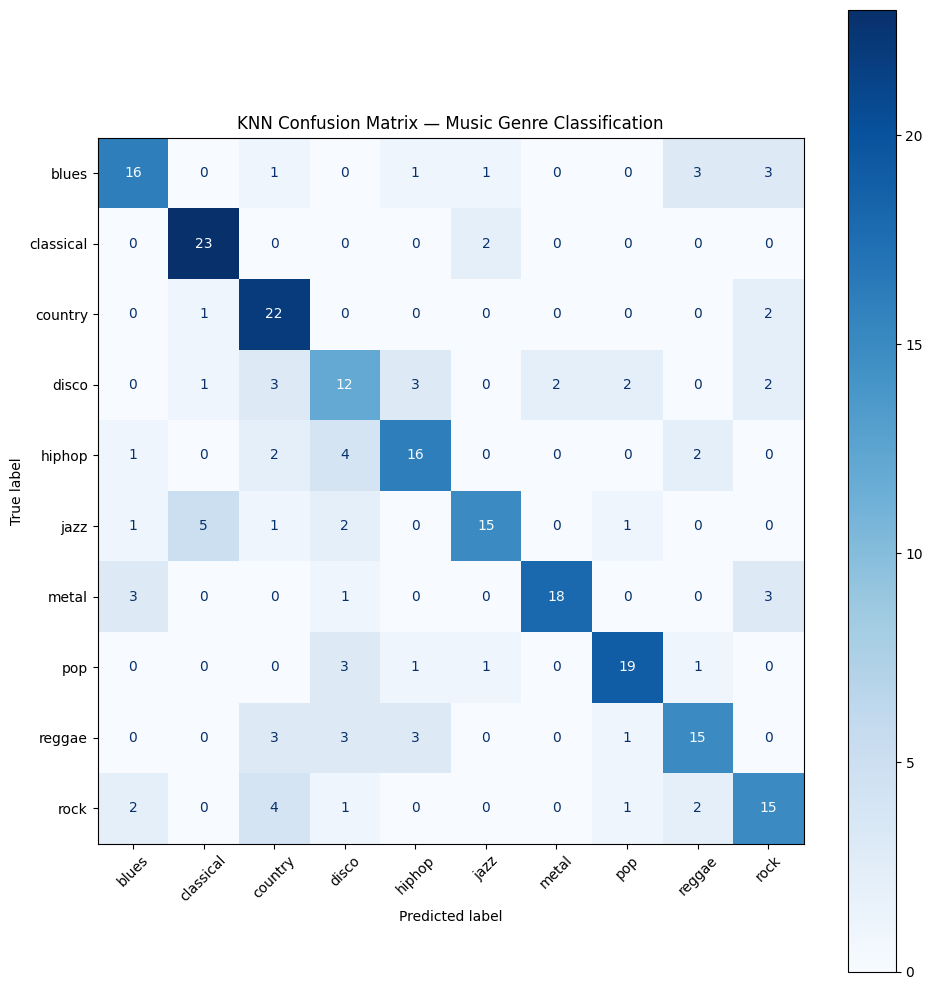

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)
plt.title("KNN Confusion Matrix — Music Genre Classification")
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Test Accuracy:", acc_svm)

SVM Test Accuracy: 0.732


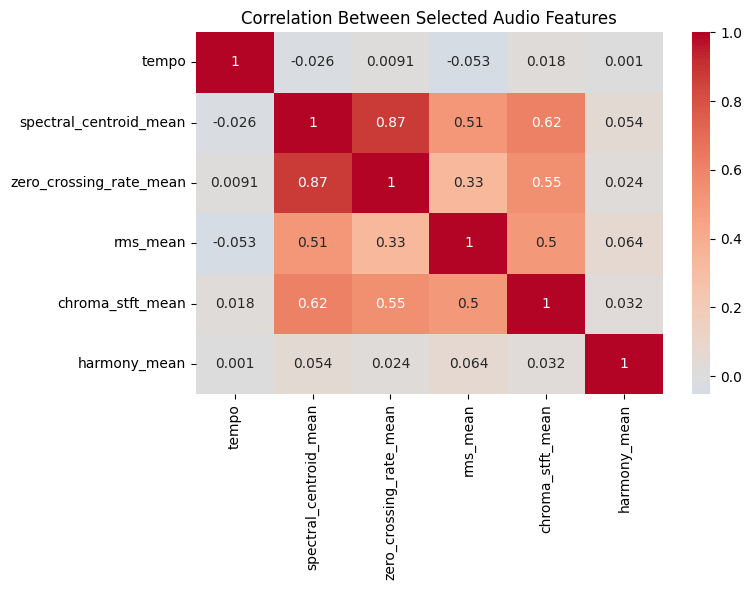

In [ ]:
import seaborn as sns

# Pick a few interesting features to check correlation
features_to_check = ['tempo', 'spectral_centroid_mean', 'zero_crossing_rate_mean',
                      'rms_mean', 'chroma_stft_mean', 'harmony_mean']

corr = df[features_to_check].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Selected Audio Features')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()

In [ ]:
X = df.iloc[:, :-1]

In [ ]:
print(df.columns)

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

In [ ]:
print(X.shape)

(1000, 59)


In [ ]:
print(X.columns)

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var'],
 

In [ ]:
print(df.iloc[:, 1:-1].columns)

Index(['length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var',
       'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var'],
      dtype='

In [ ]:
import joblib

joblib.dump(knn, "knn_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
import joblib

joblib.dump(knn, "knn_model_new.pkl")

print("Done")

Done


In [ ]:
import joblib

joblib.dump(model, "knn_model.pkl")
print("✅ Model saved successfully as knn_model.pkl")

✅ Model saved successfully as knn_model.pkl


In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
from google.colab import files

files.download("knn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'knn_model.pkl', 'knn_confusion_matrix.png', 'feature_correlation.png', 'features_30_sec (1).csv', 'features_30_sec.csv', 'sample_data']


In [ ]:
from google.colab import files

files.download("knn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
features = []

In [ ]:
import numpy as np

# Assuming you want to use the already scaled features as the 'features' array
# If you intend to stack different feature arrays, replace X_scaled with those arrays.
features = X_scaled

In [ ]:
features = X_scaled

In [ ]:
X_scaled


array([[-0.35013678,  0.31258717, -0.01068969, ..., -0.30059734,
         0.60406407, -0.51298758],
       [-0.46248155,  1.11757233, -0.53285232, ..., -0.40708699,
         0.42412706, -0.53842129],
       [-0.18422456, -0.13770124,  0.67997762, ..., -0.52729705,
        -0.29618888, -0.8749539 ],
       ...,
       [ 0.65463736, -1.43198917, -0.75062494, ..., -0.63865065,
        -0.26361549, -0.89060474],
       [-0.19833855,  0.66814351, -0.71697762, ..., -0.5114848 ,
        -0.65064889, -0.63768256],
       [-0.2483391 , -0.05894495, -1.1648952 , ...,  0.16033426,
         0.5868411 , -0.4526752 ]])

In [ ]:
X_scaled = scaler.transform(features)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
scaler.transform(features)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-9.00257121e+00,  2.98827615e+01, -2.19337102e+00, ...,
        -1.76435482e+00,  4.29217432e-01, -1.51876640e+00],
       [-1.03917507e+01,  1.36195543e+02, -1.03196960e+01, ...,
        -1.76718390e+00,  3.83363109e-01, -1.51931044e+00],
       [-6.95101270e+00, -2.95859303e+01,  8.55536258e+00, ...,
        -1.77037747e+00,  1.99801088e-01, -1.52650902e+00],
       ...,
       [ 3.42178747e+00, -2.00519952e+02, -1.37088530e+01, ...,
        -1.77333576e+00,  2.08101941e-01, -1.52684379e+00],
       [-7.12553671e+00,  7.68403765e+01, -1.31852056e+01, ...,
        -1.76995739e+00,  1.09472120e-01, -1.52143368e+00],
       [-7.74380973e+00, -1.91847446e+01, -2.01560680e+01, ...,
        -1.75210943e+00,  4.24828409e-01, -1.51747629e+00]])

In [ ]:
df.columns

Index(['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
       'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
       'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
       'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
       'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
       'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
       'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
       'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
       'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
       'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
       'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
       'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
  

In [ ]:
def extract_features(file):
    y, sr = librosa.load(file, duration=30)

    features = []

    # length
    features.append(len(y))

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features.append(np.mean(chroma))
    features.append(np.var(chroma))

    # RMS
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.var(rms))

    # Spectral centroid
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(centroid))
    features.append(np.var(centroid))

    # Spectral bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(bandwidth))
    features.append(np.var(bandwidth))

    # Rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.append(np.mean(rolloff))
    features.append(np.var(rolloff))

    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.var(zcr))

    # Harmony and perceptr
    y_harmonic, y_percussive = librosa.effects.hpss(y)

    features.append(np.mean(y_harmonic))
    features.append(np.var(y_harmonic))

    features.append(np.mean(y_percussive))
    features.append(np.var(y_percussive))

    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features.append(float(tempo))

    # MFCC 20
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    for i in range(20):
        features.append(np.mean(mfcc[i]))
        features.append(np.var(mfcc[i]))

    return np.array(features).reshape(1, -1)

In [ ]:
print(features.shape)

(1000, 57)


In [ ]:
prediction = model.predict(features)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
import joblib

joblib.dump(knn_model, "knn_model.pkl")

print("Model saved successfully")

Model saved successfully
